In [164]:
#Customer churn prediction


In [165]:
# Problem statement


# Telecom companies often lose customers due to many reasons such as poor customer support,
# cost issues or poor service

# The goal of this project is to develope a machine learning model that can predict
# whether a customer is more likely to churn based on their information such as 
# account details,billing info and subscribed services.By 
# identifying customers who are at risk of churn,company
# can take proactive measures such as offering personalized discounts,providingg 
# personalized special plans and improving customer support



In [166]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [167]:
#loading dataset
df = pd.read_csv("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [168]:
#dataset understanding
df.shape

(7043, 21)

In [169]:
print(df.info)

<bound method DataFrame.info of       customerID  gender  SeniorCitizen Partner Dependents  tenure  \
0     7590-VHVEG  Female              0     Yes         No       1   
1     5575-GNVDE    Male              0      No         No      34   
2     3668-QPYBK    Male              0      No         No       2   
3     7795-CFOCW    Male              0      No         No      45   
4     9237-HQITU  Female              0      No         No       2   
...          ...     ...            ...     ...        ...     ...   
7038  6840-RESVB    Male              0     Yes        Yes      24   
7039  2234-XADUH  Female              0     Yes        Yes      72   
7040  4801-JZAZL  Female              0     Yes        Yes      11   
7041  8361-LTMKD    Male              1     Yes         No       4   
7042  3186-AJIEK    Male              0      No         No      66   

     PhoneService     MultipleLines InternetService OnlineSecurity  ...  \
0              No  No phone service             DSL 

In [170]:
df.describe

<bound method NDFrame.describe of       customerID  gender  SeniorCitizen Partner Dependents  tenure  \
0     7590-VHVEG  Female              0     Yes         No       1   
1     5575-GNVDE    Male              0      No         No      34   
2     3668-QPYBK    Male              0      No         No       2   
3     7795-CFOCW    Male              0      No         No      45   
4     9237-HQITU  Female              0      No         No       2   
...          ...     ...            ...     ...        ...     ...   
7038  6840-RESVB    Male              0     Yes        Yes      24   
7039  2234-XADUH  Female              0     Yes        Yes      72   
7040  4801-JZAZL  Female              0     Yes        Yes      11   
7041  8361-LTMKD    Male              1     Yes         No       4   
7042  3186-AJIEK    Male              0      No         No      66   

     PhoneService     MultipleLines InternetService OnlineSecurity  ...  \
0              No  No phone service             DS

In [171]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [172]:
df['Churn'].head()

0     No
1     No
2    Yes
3     No
4    Yes
Name: Churn, dtype: str

In [173]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [174]:
df["Churn"].value_counts(normalize=True)*100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [175]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [176]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [177]:
df.TotalCharges.isnull().sum()

np.int64(0)

In [178]:
df["TotalCharges"].dtype

<StringDtype(storage='python', na_value=nan)>

In [179]:
df["TotalCharges"].head(10)

0      29.85
1     1889.5
2     108.15
3    1840.75
4     151.65
5      820.5
6     1949.4
7      301.9
8    3046.05
9    3487.95
Name: TotalCharges, dtype: str

In [180]:
df["TotalCharges"] = df["TotalCharges"].replace(" ",np.nan)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"])
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

In [181]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [182]:
df["TotalCharges"].isnull().sum()

np.int64(0)

In [183]:
churn_counts = df["Churn"].value_counts()

churn_counts

Churn
No     5174
Yes    1869
Name: count, dtype: int64

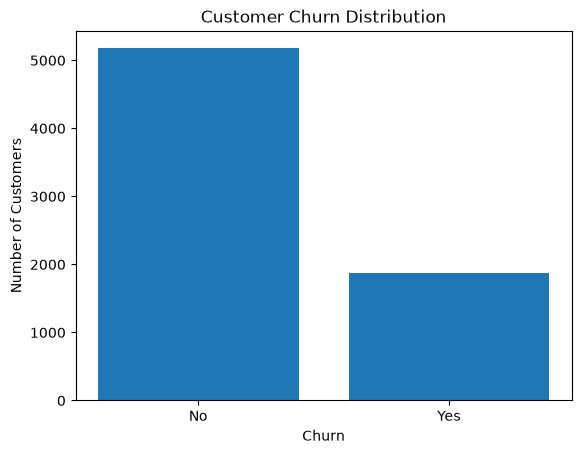

In [184]:
plt.bar(
    churn_counts.index,
    churn_counts.values
)

plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.title("Customer Churn Distribution")

plt.show()

In [185]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
)

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


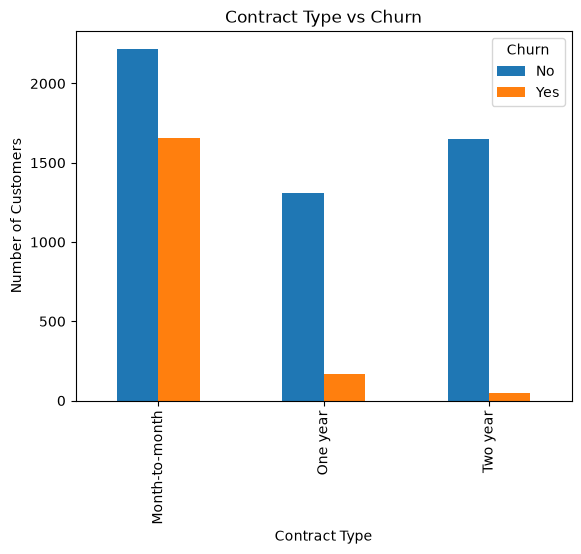

In [186]:
contract_churn.plot(
    kind="bar"
)

plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.title("Contract Type vs Churn")

plt.show()

In [187]:
def churn_cols(col):
    churn_per = pd.crosstab(df[col],df['Churn'],normalize = 'index')*100
    return churn_per.Yes.sort_values() 
    

In [188]:
churn_cols('InternetService')

InternetService
No              7.404980
DSL            18.959108
Fiber optic    41.892765
Name: Yes, dtype: float64

In [189]:
churn_cols('Contract')

Contract
Two year           2.831858
One year          11.269518
Month-to-month    42.709677
Name: Yes, dtype: float64

In [190]:
churn_cols("PaymentMethod")

PaymentMethod
Credit card (automatic)      15.243101
Bank transfer (automatic)    16.709845
Mailed check                 19.106700
Electronic check             45.285412
Name: Yes, dtype: float64

In [191]:
churn_cols("OnlineSecurity")

OnlineSecurity
No internet service     7.404980
Yes                    14.611194
No                     41.766724
Name: Yes, dtype: float64

In [192]:
churn_cols("SeniorCitizen")

SeniorCitizen
0    23.606168
1    41.681261
Name: Yes, dtype: float64

In [193]:
df.groupby("Churn")["tenure"].mean()


Churn
No     37.569965
Yes    17.979133
Name: tenure, dtype: float64

In [194]:
df.groupby("Churn")["MonthlyCharges"].mean()

Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64

In [195]:
df.groupby("Churn")["TotalCharges"].mean()

Churn
No     2552.882494
Yes    1531.796094
Name: TotalCharges, dtype: float64

In [196]:
df.drop("customerID", axis=1, inplace=True)

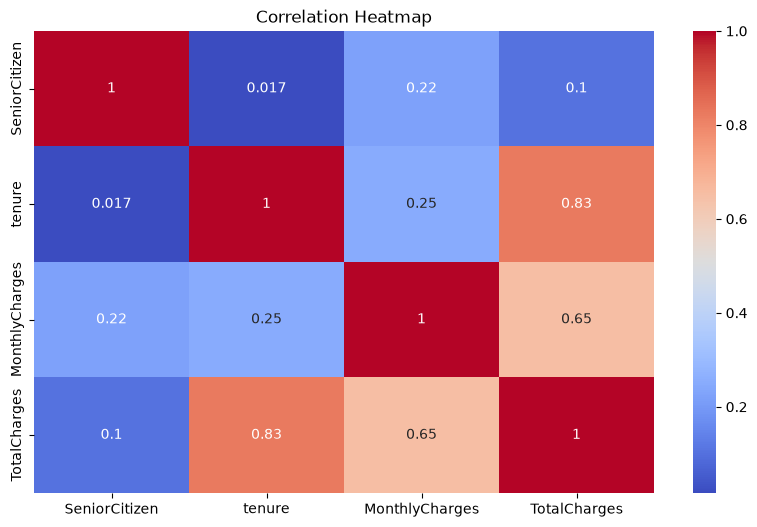

In [197]:
plt.figure(figsize=(10,6))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.show()

In [198]:
df["Churn_numeric"] = df["Churn"].map({"Yes": 1, "No": 0})

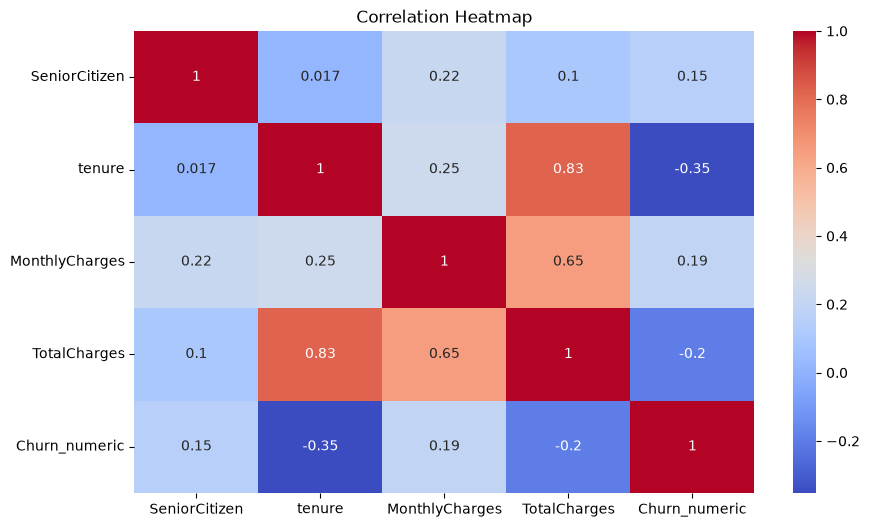

In [199]:
plt.figure(figsize=(10,6))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.show()

In [200]:
#data cleaning
df.drop("Churn_numeric", axis=1, inplace=True)

In [201]:
y = df["Churn"]
X = df.drop("Churn", axis=1)
y = df["Churn"].map({"No": 0,"Yes": 1})

In [202]:
X.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65


In [203]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2,random_state=1)

In [204]:
num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns
num_cols

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='str')

In [205]:
cat_cols = X_train.select_dtypes(include=["object"]).columns
cat_cols

C:\Users\rohan\AppData\Local\Temp\ipykernel_25148\827758852.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train.select_dtypes(include=["object"]).columns


Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='str')

In [206]:
#building models
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

In [207]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

In [208]:
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [209]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ]
)

In [210]:
from sklearn.linear_model import LogisticRegression

In [211]:
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

In [212]:
model.fit(X_train,y_train)
y_pred = model.predict(X_test)

In [213]:
from sklearn.metrics import (confusion_matrix,classification_report)

In [214]:
cm = confusion_matrix(y_test,y_pred)
cm

array([[939, 122],
       [144, 204]])

In [215]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.87      0.89      0.88      1061
           1       0.63      0.59      0.61       348

    accuracy                           0.81      1409
   macro avg       0.75      0.74      0.74      1409
weighted avg       0.81      0.81      0.81      1409



In [216]:
X.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges'],
      dtype='str')

In [217]:
model = Pipeline(steps=[('preprocessor',preprocessor),('classifier',LogisticRegression(max_iter = 1000,class_weight = 'balanced'))])

In [218]:
model.fit(X_train,y_train)
y_pred = model.predict(X_test)

C:\Users\rohan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [219]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.73      0.82      1061
           1       0.50      0.83      0.63       348

    accuracy                           0.76      1409
   macro avg       0.72      0.78      0.72      1409
weighted avg       0.82      0.76      0.77      1409



In [220]:
from sklearn.metrics import roc_auc_score
y_prob = model.predict_proba(X_test)[:,1]
roc_auc_score(y_test, y_prob)

0.8584600842839655

In [221]:
from sklearn.ensemble import RandomForestClassifier
rf_model = Pipeline(steps=[('preprocessor',preprocessor),('classifier',RandomForestClassifier(n_estimators = 300,random_state = 1,max_depth = 5,class_weight = 'balanced'))])

In [222]:
rf_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [223]:
rf_pred = rf_model.predict(X_test)

In [224]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.93      0.72      0.81      1061
           1       0.49      0.83      0.62       348

    accuracy                           0.74      1409
   macro avg       0.71      0.77      0.71      1409
weighted avg       0.82      0.74      0.76      1409



In [225]:
rf_prob = rf_model.predict_proba(X_test)[:,1]
roc_auc_score(y_test, rf_prob)

0.8543393242115982

In [226]:
from sklearn.metrics import accuracy_score
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, rf_pred)],
    "ROC-AUC": [
        roc_auc_score(y_test, model.predict_proba(X_test)[:,1]),
        roc_auc_score(y_test, rf_prob)]})
results

,Model,Accuracy,ROC-AUC
0,Logistic Regression,0.755145,0.858460
1,Random Forest,0.744500,0.854339


In [227]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.93      0.72      0.81      1061
           1       0.49      0.83      0.62       348

    accuracy                           0.74      1409
   macro avg       0.71      0.77      0.71      1409
weighted avg       0.82      0.74      0.76      1409



In [228]:
#
# Among the evaluated models, Logistic Regression with balanced class
# weights achieved the best balance for this business problem, with
# a ROC-AUC of 0.858 and a churn recall of 0.83. While Random Forest 
# achieved competitive performance, Logistic Regression provided slightly 
# better ranking ability and overall metrics ###

In [229]:
from xgboost import XGBClassifier

In [230]:
xgb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        random_state=42))
])

In [231]:
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:,1]

In [232]:
xgb_model.score(X_test,y_test)

0.7991483321504613

In [233]:
print(classification_report(y_test,xgb_pred))

              precision    recall  f1-score   support

           0       0.86      0.88      0.87      1061
           1       0.60      0.56      0.58       348

    accuracy                           0.80      1409
   macro avg       0.73      0.72      0.72      1409
weighted avg       0.80      0.80      0.80      1409



In [234]:
print("ROC-AUC:",roc_auc_score(y_test, xgb_prob))

ROC-AUC: 0.8342040690305177


In [235]:
#conclusion

# This project designed an end-to-end machine learning pipeline to forecast customer 
# churn within a telecom company. Cleaning the data, exploratory data analysis,
# and feature engineering via Scikit-learn Pipelines led to three machine learning 
# models being examined: Logistic Regression, Random Forest, and XGBoost.

# While XGBoost delivered the highest level of accuracy, Logistic 
# Regression with balancing classes yielded the best results for the 
# problem of customer retention. It had the highest value of recall for
# the class “churn” (0.83) and the best ROC-AUC score (0.858).

# This project shows the whole machine learning pipeline, including data 
# preparation, model training and testing, handling of class imbalance, and 
# comparing several algorithms.


In [236]:
from sklearn.metrics import accuracy_score
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
    "XGBoost"],
        
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred)],
    "ROC-AUC": [
        roc_auc_score(y_test, model.predict_proba(X_test)[:,1]),
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, xgb_prob)]})
results

,Model,Accuracy,ROC-AUC
0,Logistic Regression,0.755145,0.858460
1,Random Forest,0.744500,0.854339
2,XGBoost,0.799148,0.834204


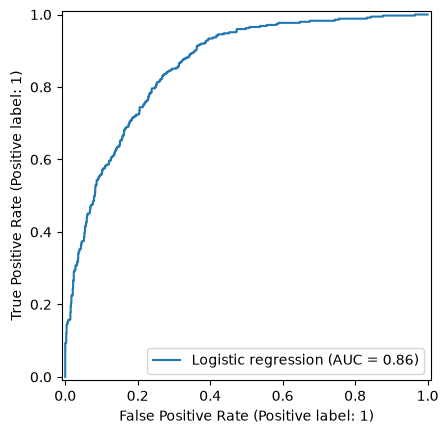

In [237]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt 
RocCurveDisplay.from_estimator(model,X_test,y_test,name='Logistic regression')

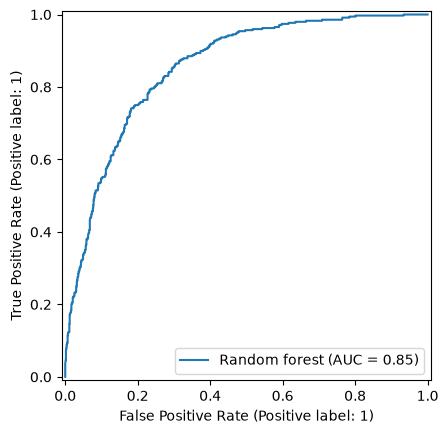

In [238]:
RocCurveDisplay.from_estimator(rf_model,X_test,y_test,name='Random forest')

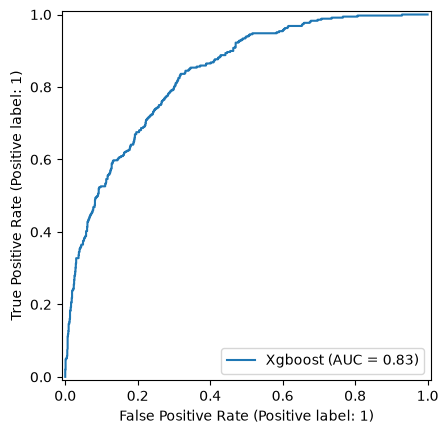

In [239]:
RocCurveDisplay.from_estimator(xgb_model,X_test,y_test,name='Xgboost')

In [ ]:
### ROC Curve Analysis

# The ROC curve comparison shows that Logistic Regression achieved the highest 
# AUC score, indicating better separation between churn and non-churn customers. While XGBoost 
# achieved higher accuracy, Logistic Regression provides better ranking capability and recall for
# the churn class, which is more important for customer retention.

In [243]:
import joblib
joblib.dump(model, "customer_churn_model.pkl")

['customer_churn_model.pkl']

In [244]:
loaded_model = joblib.load("customer_churn_model.pkl")

In [245]:
prediction = loaded_model.predict(X_test)
prediction[:10]

array([0, 0, 1, 1, 0, 0, 1, 1, 0, 0])

In [246]:
model.predict(X_test)[:10]

array([0, 0, 1, 1, 0, 0, 1, 1, 0, 0])